In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

In [312]:
df=pd.read_parquet('/Users/huangshifeng/Desktop/ML_Learning_Curve/data_typed.parquet', engine='pyarrow')

print("Data shape:", df.shape)
print("Columns preview:", df.columns.tolist())
print(df["approach"].value_counts(dropna=False))

Data shape: (304, 26)
Columns preview: ['Patient_ID', 'Gender', 'OP_Year', 'Age', 'BMI', 'ASA', 'Procedure_1', 'Protective_Stoma', 'Procedure_Time(min)', 'Blood_Loss', 'Conv_to_Open', 'Time_1stFlatus(d)', 'LengthStay', 'Major_Complications', 'Anastomotic_Leakage', 'Unplanned_ICU_Admission', 'Mortality_30days', 'Neoadjuvant', 'Composite_Adverse_Event', 'Is_Rectum', 'From_Anal_Verge(cm)', 'Tumor_Size(cm)', 'Distal_Margin(cm)', 'CRM_positivity', 'No_LNs', 'approach']
approach
0    211
1     93
Name: count, dtype: int64


### 用'approach'欄位區分兩個cohort

In [313]:
df_lap = df[df["approach"] == 0].copy()
df_robot = df[df["approach"] == 1].copy()

print("Lapa cohort:", df_lap.shape)
print("Robot cohort:", df_robot.shape)

Lapa cohort: (211, 26)
Robot cohort: (93, 26)


### 定義目標變數和特徵變數
特徵變數可以不斷更改直到找到最佳模型

In [314]:
target_col = 'Composite_Adverse_Event'
ord_features=[]
nom_features=[]
bin_features=['Is_Rectum']
num_features=['ASA', 'Age', 'BMI']

total_features = ord_features+nom_features+bin_features+num_features

print("Number of features:", len(total_features))

Number of features: 4


### 定義訓練集的X和y

In [315]:
X_lap = df_lap[total_features]
y_lap = df_lap[target_col]

### 設計前處理階段的transformers

In [316]:
numeric_transformer = Pipeline(steps=[
    # 先補缺值，用 median
    ("imputer", SimpleImputer(strategy="median")),
    # 再做標準化：減平均 / 除以標準差
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
    # 通常不用 scaler，0/1 本來就很好解讀
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("bin", binary_transformer, bin_features),
    ],
    remainder="drop"  # 其他沒列到的欄位全部丟掉
)

### 設計核心模型
以LogisticRegression為例，
penalty可以使用l1/l2/elasticnet，
elasticnet會多一個參數l1_ratio
n_jobs代表要不要用CPU多核心運算加速，-1表示電腦有幾核心就用幾核心，全開

建立clf = classifier pipeline：前處理 -> 核心模型 

In [317]:
log_reg = LogisticRegression(
    solver="saga",       # 支援 L1 / elasticnet
    penalty="l2",        # elasticnet
    max_iter=10000,
    n_jobs=None            # 多核心加速
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

### 用5倍CV看一下模型在調參前的baseline表現

5-Fold cross validation會把資料分成5份，
每一次都用其中1份當作測試集，其他4份當作訓練集;
'scoring'參數可以調整報的指標，這裡是ROC curve的AUC
5次的平均就是5-fold mean CV AUC

In [318]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# X_lap, y_lap 是你的 Lapa cohort features & target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    clf,
    X_lap,
    y_lap,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1   # 這裡可以用 -1 平行跑 folds
)

print("5-fold CV AUCs:", cv_auc)
print("Mean CV AUC:", cv_auc.mean(), "±", cv_auc.std())


5-fold CV AUCs: [0.64864865 0.55135135 0.59459459 0.75       0.78240741]
Mean CV AUC: 0.6654004004004004 ± 0.08848615807311848


### 調整參數C和class_weight等等超參數，作GridSearch
所謂的GridSearch就是把所有可能的超參數組合都列出來，一個一個拿來試試看；
以logistic而言可以調的超參數有C和class_weight，如果是elasticnet則還有l1_ratio可以拿來調

In [319]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": np.logspace(-3, 2, 6),   # [0.001, 0.01, 0.1, 1, 10, 100]
    "model__class_weight": [None, "balanced"]
}

In [320]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=clf,          # 你剛剛那條 pipeline
    param_grid=param_grid,  # 上面設計好的參數組合
    scoring="roc_auc",      # 以 AUC 當目標
    cv=cv,                  # 5-fold StratifiedKFold
    n_jobs=-1,              # 平行跑
    refit=True              # ★ 預設就是 True：找到最佳參數後，用全部資料重訓一模型
)

grid.fit(X_lap, y_lap)
print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Best params: {'model__C': np.float64(10.0), 'model__class_weight': None}
Best CV AUC: 0.6673073073073074


### 對 5-fold CV AUC 做 bootstrap
每次重抽一個 bootstrap sample，重算一次 5-fold CV AUC，最後用 AUC 分布算平均跟 95% CI（percentile 法）。

In [321]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

def bootstrap_cv_auc(clf, X, y, n_bootstrap=1000, random_state=42):
    """
    對 5-fold CV AUC 做 bootstrap：
    每次重抽一個 bootstrap sample，重算一次 5-fold CV AUC，
    最後用 AUC 分布算平均跟 95% CI（percentile 法）。
    """
    rng = np.random.RandomState(random_state)
    n = len(y)
    aucs = []

    for b in range(n_bootstrap):
        # 1) 重抽 n 個 index（有放回抽樣）
        indices = rng.randint(0, n, n)

        # 2) 取出這一個 bootstrap 樣本
        X_b = X.iloc[indices] if hasattr(X, "iloc") else X[indices]
        y_b = y.iloc[indices] if hasattr(y, "iloc") else y[indices]

        # 3) 在這個 bootstrap 樣本上再做一次 5-fold CV AUC
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc_b = cross_val_score(
            clf,
            X_b,
            y_b,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        ).mean()

        aucs.append(auc_b)

    aucs = np.array(aucs)
    mean_auc = aucs.mean()
    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return mean_auc, lower, upper, aucs

mean_auc, lower, upper, aucs = bootstrap_cv_auc(
    clf,
    X_lap,
    y_lap,
    n_bootstrap=1000,   # 先 500 也可以，跑比較快
    random_state=42
)

print(f"Bootstrap 5-fold CV AUC (mean): {mean_auc:.3f}")
print(f"95% CI (percentile): {lower:.3f} – {upper:.3f}")


Bootstrap 5-fold CV AUC (mean): 0.684
95% CI (percentile): 0.530 – 0.805


In [322]:
print("Fitting model on Lap cohort...")
clf.fit(X_lap, y_lap)

print("Training done.")

Fitting model on Lap cohort...
Training done.


### 在訓練集上簡單看一下 performance（不是 CV，只是 sanity check）
這是用全部的資料做的，叫做apparent AUC，通常會較樂觀

In [323]:
#在訓練集上簡單看一下 performance（不是 CV，只是 sanity check）
y_lap_pred = clf.predict(X_lap)
y_lap_proba = clf.predict_proba(X_lap)[:, 1]

print("Model Accuracy:", accuracy_score(y_lap, y_lap_pred))
print("Model AUC:", roc_auc_score(y_lap, y_lap_proba))
print(classification_report(y_lap, y_lap_pred))

Model Accuracy: 0.8672985781990521
Model AUC: 0.7162373145979704
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       183
           1       0.00      0.00      0.00        28

    accuracy                           0.87       211
   macro avg       0.43      0.50      0.46       211
weighted avg       0.75      0.87      0.81       211



/Users/huangshifeng/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/huangshifeng/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/huangshifeng/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

### 開始來畫CUSUM Plot

In [ ]:
#先把robotic cases依照時間排序
df_robot = df_robot.sort_values("Patient_ID")

In [324]:
#定義特徵和outcome
y_robot = df_robot[target_col].values
X_robot = df_robot[total_features]

In [326]:
# 用 Lapa fit 好的 best_clf 對 robotic case 算預測機率
p_robot = clf.predict_proba(X_robot)[:, 1]  # class=1 的機率

df_robot["p_hat"] = p_robot
df_robot["y"] = y_robot

print("Robot event rate:", df_robot["y"].mean())
print("p_hat percentiles:", np.percentile(df_robot["p_hat"], [5, 25, 50, 75, 95]))

Robot event rate: 0.12903225806451613
p_hat percentiles: [0.0439674  0.09011525 0.13274832 0.18209789 0.29973075]


In [328]:
# 計算RA-CUSUM，逐台累積 (observed - expected)
df_robot["diff"] = df_robot["y"] - df_robot["p_hat"]
df_robot["RA_CUSUM"] = df_robot["diff"].cumsum()

In [329]:
# 沒有Risk adjustment的CUSUM
overall_rate = df_robot["y"].mean()
df_robot["diff_unadj"] = df_robot["y"] - overall_rate
df_robot["CUSUM_unadj"] = df_robot["diff_unadj"].cumsum()

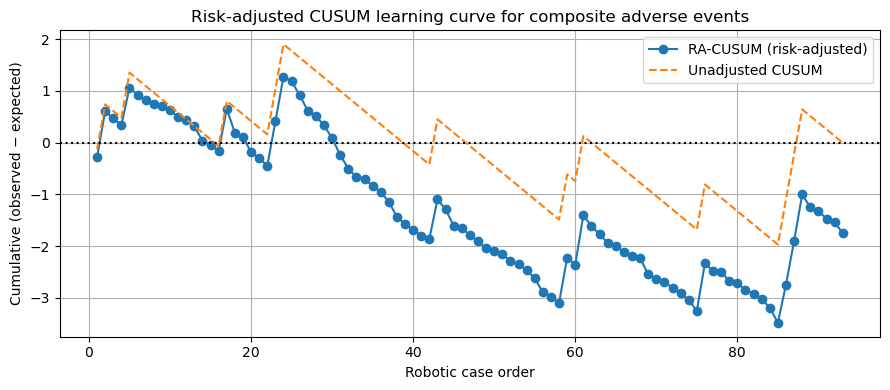

In [330]:
# 用matplotlib畫出CUSUM曲線
plt.figure(figsize=(9, 4))
plt.plot(df_robot["Patient_ID"], df_robot["RA_CUSUM"], marker="o", label="RA-CUSUM (risk-adjusted)")

# 如果你有算 unadjusted，就一起畫：
plt.plot(df_robot["Patient_ID"], df_robot["CUSUM_unadj"], linestyle="--", label="Unadjusted CUSUM")

plt.axhline(0, color="black", linestyle=":")  # 基準線

plt.xlabel("Robotic case order")
plt.ylabel("Cumulative (observed − expected)")
plt.title("Risk-adjusted CUSUM learning curve for composite adverse events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [332]:
# 1. RA-CUSUM 最後一點是不是 sum(y - p_hat)
df_robot["diff"] = df_robot["y"] - df_robot["p_hat"]
print(df_robot["diff"].sum(), df_robot["RA_CUSUM"].iloc[-1])

# 2. 比較跨段的實際 vs 預測風險
for start, end in [(1, 30), (31, 60), (61, 93)]:
    seg = df_robot[(df_robot["Patient_ID"] >= start) & (df_robot["Patient_ID"] <= end)]
    print(f"{start}-{end} cases:",
          "obs rate =", seg["y"].mean(),
          "mean p_hat =", seg["p_hat"].mean())

-1.749365456191371 -1.749365456191371
1-30 cases: obs rate = 0.16666666666666666 mean p_hat = 0.16374396154305831
31-60 cases: obs rate = 0.06666666666666667 mean p_hat = 0.1480761466156632
61-93 cases: obs rate = 0.15151515151515152 mean p_hat = 0.13317461246756743


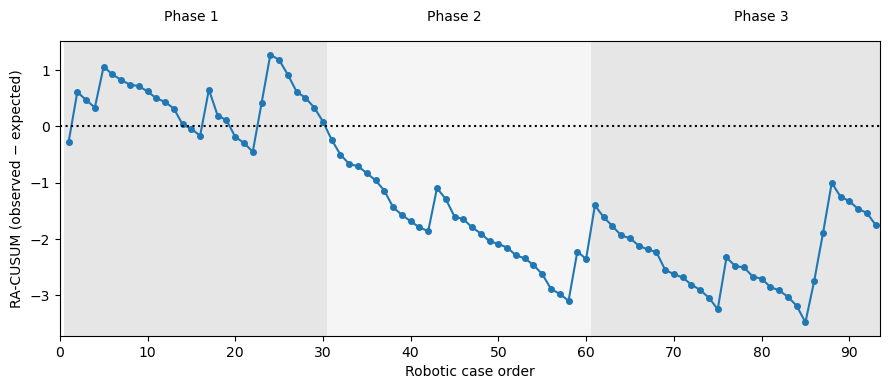

<Figure size 640x480 with 0 Axes>

In [352]:
fig, ax = plt.subplots(figsize=(9, 4))

# 先決定 x 軸範圍
xmin = df_robot["Patient_ID"].min() - 0.5   # 例如 0.5
xmax = df_robot["Patient_ID"].max() + 0.5   # 例如 93.5
ax.set_xlim(xmin, xmax)

# Phase 1
ax.axvspan(xmin, 30.5, facecolor="0.90", zorder=0, edgecolor="none")
# Phase 2
ax.axvspan(30.5, 60.5, facecolor="0.96", zorder=0, edgecolor="none")
# Phase 3
ax.axvspan(60.5, xmax, facecolor="0.90", zorder=0, edgecolor="none")

ax.plot(df_robot["Patient_ID"], df_robot["RA_CUSUM"],
         marker="o", markersize=4, color="tab:blue",
         label="RA-CUSUM")

plt.axhline(0, color="black", linestyle=":")

plt.text(15,  df_robot["RA_CUSUM"].max()+0.6, "Phase 1", ha="center")
plt.text(45,  df_robot["RA_CUSUM"].max()+0.6, "Phase 2", ha="center")
plt.text(80,  df_robot["RA_CUSUM"].max()+0.6, "Phase 3", ha="center")

plt.xlabel("Robotic case order")
plt.ylabel("RA-CUSUM (observed − expected)")
plt.xticks(([0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))
plt.tight_layout()
plt.show()

plt.savefig("RA_CUSUM.tiff",
            dpi=600,          # 解析度
            format="tiff",    # 指定格式
            bbox_inches="tight")  # 把多餘空白裁掉